In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import ifft, fft, fftfreq, fftshift, ifft2, fft2
from scipy.io import wavfile
from scipy.signal import hilbert
from audio_function import *

In [10]:
fs, data_micr_calibr =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0098S1.wav')
fs, data_pgd_calibr = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0098S2.wav')

fs, data_micr_noise_big = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0099S1.wav')
fs, data_pgd_noise_big = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0099S2.wav')

fs, data_micr_noise_small = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0102S1.wav')
fs, data_pgd_noise_small = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0102S2.wav')

fs, data_micr_stol = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0103S1.wav')
fs, data_pgd_stol = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0103S2.wav')

fs, data_micr_porolon = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0104S1.wav')
fs, data_pgd_porolon = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0104S2.wav')

fs, data_micr_self = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0100S1.wav')
fs, data_pgd_self = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0100S2.wav')

fs, data_micr_self_small = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0101S1.wav')
fs, data_pgd_self_small = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/PGD_0711/TASCAM_0101S2.wav')

In [11]:
import numpy as np

def generate_octave_bands(octave_fraction=12, f_low=80, f_high=10000, f_ref=1000):
    """
    Генерация октавных полос аналогично MATLAB коду
    
    Parameters:
    octave_fraction : int - дробность октавы (3, 6, 12, 24, 48)
    f_low : float - нижняя частота диапазона (Гц)
    f_high : float - верхняя частота диапазона (Гц) 
    f_ref : float - опорная частота (Гц)
    """
    # Вычисляем индексы как в MATLAB
    start_idx = np.round(np.log2(f_low/f_ref) * octave_fraction) + 1
    end_idx = np.round(np.log2(f_high/f_ref) * octave_fraction) - 1
    
    # Создаем диапазон индексов
    indices = np.arange(start_idx, end_idx + 1)  # +1 т.к. в Python конец не включается
    
    # Центральные частоты
    f0 = f_ref * 2.**(indices / octave_fraction)
    
    # Граничные частоты
    bandwidth_factor = 2**(1/(2*octave_fraction))
    f_down = f0 / bandwidth_factor
    f_up = f0 * bandwidth_factor
    
    return f0, f_down, f_up

# --- Примеры использования (аналогично MATLAB коду) ---

print("=== 1/12 октавы (как в активном коде) ===")
f0, f_down, f_up = generate_octave_bands(octave_fraction=12, f_low=80, f_high=10000)
# print(f"Центральные частоты: {f0}")
# print(f"Нижние границы: {f_down}")
# print(f"Верхние границы: {f_up}")


=== 1/12 октавы (как в активном коде) ===


In [12]:
# octave_boundaries = np.array([71, 89, 112, 141, 179, 224, 281, 355, 447, 561, 710, 895, 1120, 1410, 1790, 2240, 2810, 3550, 4470, 5610, 7100, 8950, 11200])
# lower_bounds = octave_boundaries[:-1]
# upper_bounds = octave_boundaries[1:]
# center_freqs = np.array([80, 100, 125, 160, 200, 250, 315, 400, 500, 630, 800, 1000, 1250, 1600, 2000, 2500, 3150, 4000, 5000, 6300, 8000, 10000])  # Центральные частоты как середина диапазона

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


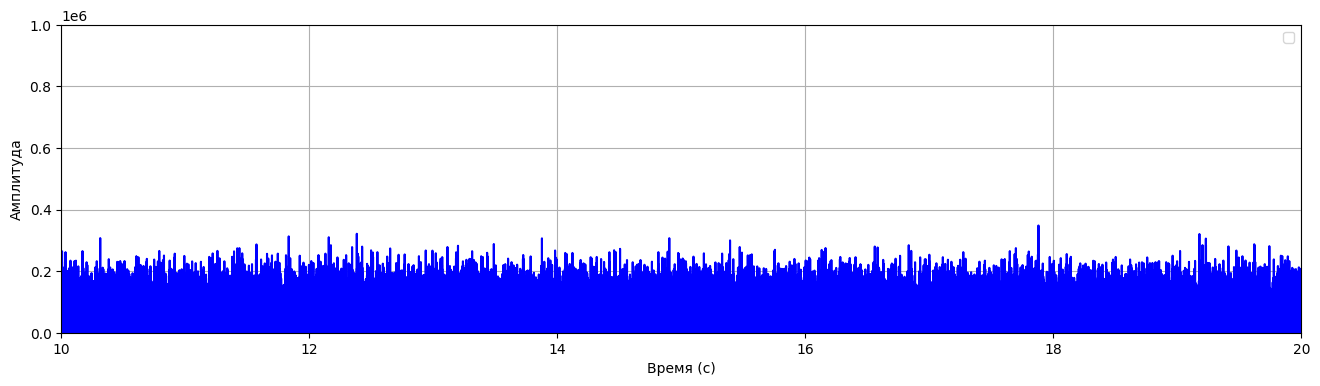

In [13]:
t_micr_calibr = np.arange(len(data_micr_calibr))/fs
f_micr_calibr = fftfreq(len(data_micr_calibr), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(t_micr_calibr, data_micr_calibr, color='blue')
plt.legend()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.xlim(10, 20)
plt.ylim(0, 1e6)
plt.show()

In [14]:
data_micr_calibr_94db = data_micr_calibr - np.mean(data_micr_calibr)
data_micr_noise_big = data_micr_noise_big - np.mean(data_micr_noise_big)
data_micr_noise_small = data_micr_noise_small - np.mean(data_micr_noise_small)

In [15]:
# Выделям временной участок, на котором калибровка чистая
t_index = (t_micr_calibr > 10) & (t_micr_calibr < 15)
t_calibr_5sec = t_micr_calibr[t_index]

data_micr_calibr_5sec = data_micr_calibr_94db[t_index]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


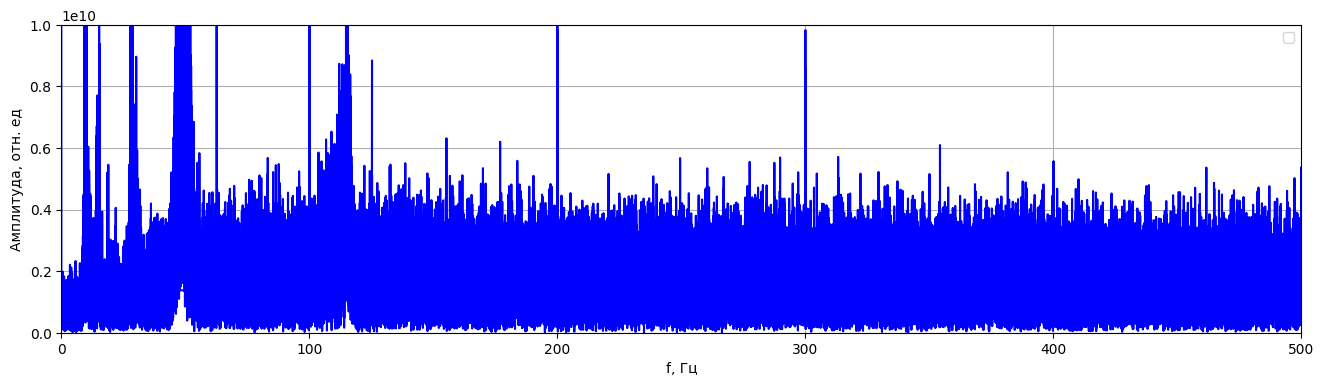

In [16]:
signal = data_micr_self
t = np.arange(len(signal))/fs
f = fftfreq(len(signal), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(f, np.abs((fft(signal))), color='blue')
plt.legend()
plt.xlabel("f, Гц")
plt.ylabel("Амплитуда, отн. ед")
plt.grid(True)
plt.xlim(0, 500)
plt.ylim(0, 1e10)
plt.show()

In [17]:
# Находим коэффициент усиления шумомера и учитываем его
data_micr_calibr_5sec = ifft(fft(data_micr_calibr_5sec))
impl_dB = 20
k_impl = 10**(impl_dB/20)

data_micr_calibr_5sec = data_micr_calibr_5sec / k_impl
data_micr_calibr = data_micr_calibr / k_impl
data_micr_noise_big = data_micr_noise_big / k_impl
data_micr_noise_small = data_micr_noise_small / k_impl
data_micr_self = data_micr_self / k_impl

# Находим коэффициента пересчета из отн. ед. в Па
k_t = RMS(data_micr_calibr_5sec)
k_to_pa = 1 / k_t
k_to_pa

1.594610350670159e-05

In [18]:
data_micr_calibr_5sec_pa = data_micr_calibr_5sec * k_to_pa
data_micr_calibr_pa = data_micr_calibr * k_to_pa
data_micr_noise_big_pa = data_micr_noise_big * k_to_pa
data_micr_noise_small_pa = data_micr_noise_small * k_to_pa
data_micr_self_pa = data_micr_self / k_to_pa

In [19]:
signal = data_micr_noise_big_pa - np.mean(data_micr_noise_big_pa)
data_micr_noise_big_pa_rms = RMS(signal)
dB_level = 20 * np.log10(data_micr_noise_big_pa_rms / 2e-5)
dB_level

124.59413650871262

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


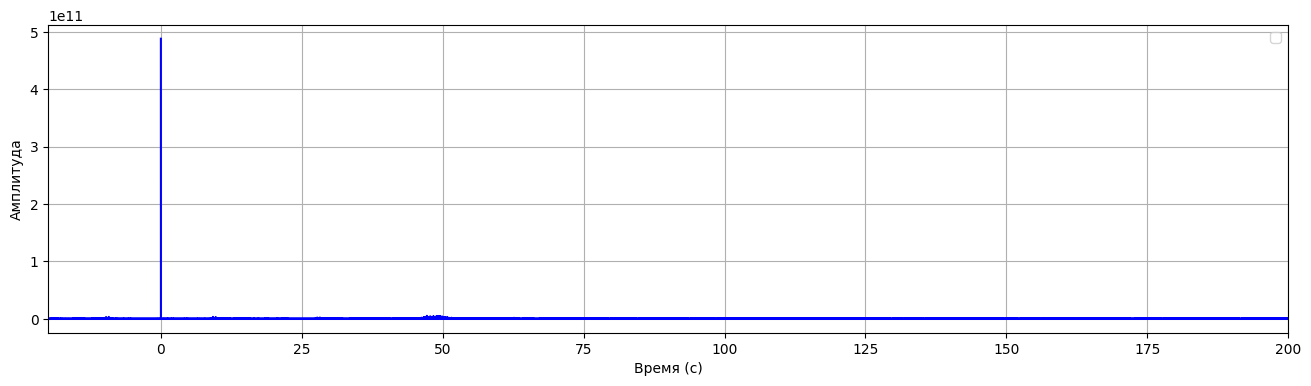

In [24]:
signal = data_micr_self
t = np.arange(len(signal))/fs
f = fftfreq(len(signal), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(f, np.abs(fft((signal))), color='blue')
plt.legend()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.xlim(-20, 200)
plt.show()